In [101]:
import pandas as pd 
import numpy as np
import os 
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.ticker import MaxNLocator

In [143]:
df = pd.read_csv("ai_chorales.csv")

In [144]:
df.shape

(1500, 17)

# Data prep

In [145]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%dT%H-%M-%S-%fZ", utc=True)

In [146]:
df.head()

,participant_id,timestamp,age,musical_experience,plays_instrument,sings_in_choir,uses_ai_weekly,confidence_before,confidence_after,difficulty,free_feedback,stimulus,response,correct,correct_response,rt,training
0,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/153.5-3.wav,x,m,False,9871,False
1,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/256-5.wav,m,m,True,7578,False
2,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/227.11-5.wav,m,m,True,9041,False
3,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/122.6-4.wav,x,m,False,9712,False
4,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/A/output48-2.wav,x,x,True,8551,False


In [147]:
df = df[[
    'participant_id', 
    'timestamp',
    'age',
    'musical_experience',
    'plays_instrument',
    'sings_in_choir',
    'uses_ai_weekly',
    'confidence_before',
    'confidence_after',
    'difficulty',
    # free_feedback,
    'stimulus',
    'response',  
    'correct',
    'correct_response',
    'rt', 
    # 'training',
        ]]

In [ ]:
# transform to 1 column per participant for categorical analyses
unique_participants = df.drop_duplicates(subset=["participant_id"])
print(f"Number of participants: {len(unique_participants)}")



Number of participants: 75


,participant_id,timestamp,age,musical_experience,plays_instrument,sings_in_choir,uses_ai_weekly,confidence_before,confidence_after,difficulty,stimulus,response,correct,correct_response,rt
0,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/153.5-3.wav,x,m,False,9871
20,49e8cb9f-00a0-4469-b2e6-33b7c420825b,2026-05-13 13:45:02.945000+00:00,18,sehr unerfahren,nein,nein,ja,sehr unsicher,sehr unsicher,sehr schwer,data/H/283-7.wav,m,m,True,8181
40,fe0f99d8-d9a8-4eed-b1bc-7d638725aa63,2026-05-13 14:56:55.653000+00:00,52,erfahren,ja,ja,ja,unsicher,sehr unsicher,sehr schwer,data/H/175.5-5.wav,x,m,False,7731
60,697ec336-fe2e-419f-8200-408a6bc1c7b2,2026-05-13 15:11:24.970000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/244.15-6.wav,m,m,True,3819
80,94a11270-e293-4b08-acfc-a37f3732dfd6,2026-05-13 16:25:30.143000+00:00,74,unerfahren,nein,nein,nein,sehr unsicher,unsicher,sehr schwer,data/H/175.5-5.wav,m,m,True,11611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1400,6ac8089d-17ba-4536-afb5-63153a00dd6c,2026-07-08 15:05:47.339000+00:00,21,erfahren,ja,nein,ja,sehr unsicher,sehr unsicher,sehr schwer,data/A/output3-3.wav,m,x,False,12850
1420,fc2c991e-93cb-4d00-8e82-7f8fd994ff32,2026-07-08 15:05:15.261000+00:00,23,erfahren,ja,ja,nein,unsicher,unsicher,schwer,data/A/output26-4.wav,m,x,False,10679
1440,45a24faf-a8d1-49fe-9e80-cbbcbb60a44d,2026-07-08 15:05:44.499000+00:00,25,erfahren,nein,ja,ja,sicher,unsicher,schwer,data/A/output16-1.wav,x,x,True,14309
1460,4caee2ed-9998-4b88-9e9c-3f529b9922c2,2026-07-08 15:06:00.823000+00:00,23,erfahren,ja,ja,ja,unsicher,unsicher,schwer,data/H/227.11-5.wav,m,m,True,12018


# Data eval

Mean:   25.4
Median: 23.0


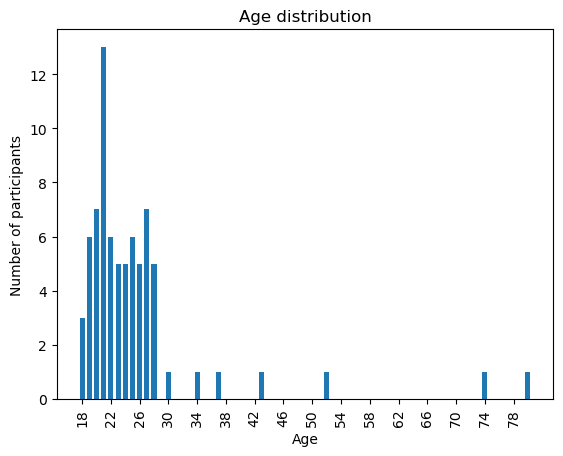

In [ ]:

# Age distribution

unique_ages = unique_participants["age"]

age_min, age_max = int(unique_ages.min()), int(unique_ages.max())
unique_ages.plot(
    kind="hist", 
    bins=range(age_min, age_max + 2), 
    align='left',
    rwidth=0.7, # Adds a slight gap between bars for readability
    ylabel="Number of participants", 
    xlabel="Age",
    title="Age distribution"
)



plt.xticks(range(age_min, age_max + 1, 4))
plt.xticks(rotation=90)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# print metrics
print("Mean:  ", round(unique_ages.mean(), 1))
print("Median:", unique_ages.median())

plt.show()

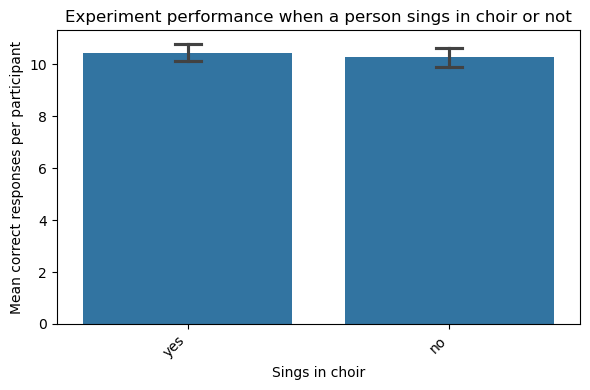

In [149]:
# Average correct repsonses by sings_in_choir

translation_dict = {"ja": "yes", "nein": "no"}

df["sings_in_choir"] = df["sings_in_choir"].map(translation_dict)

participant_summary = (
    df.groupby(["participant_id", "sings_in_choir"], as_index=False)["correct_response"]
    .sum()
)

order = ["yes", "no"]

plt.figure(figsize=(6, 4))
sns.barplot(
    data=participant_summary,
    x="sings_in_choir",
    order=order,
    y="correct_response",
    errorbar="se",
    capsize=0.1
)
plt.ylabel("Mean correct responses per participant")
plt.xlabel("Sings in choir")
plt.title("Experiment performance when a person sings in choir or not")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


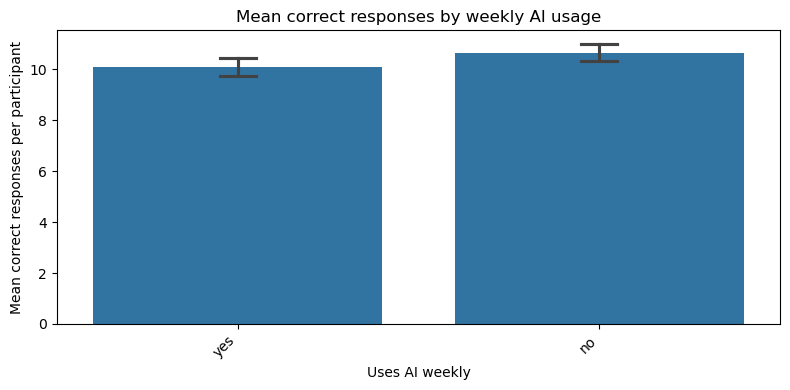

In [141]:
# Average correct responses by weekly ai usage

translation_dict = {"ja": "yes", "nein": "no"}

df["uses_ai_weekly"] = df["uses_ai_weekly"].map(translation_dict)
participant_summary = (
    df.groupby(["participant_id", "uses_ai_weekly"], as_index=False)["correct_response"]
    .sum()
)



order = ["yes", "no"]
plt.figure(figsize=(8, 4))
sns.barplot(
    data=participant_summary,
    x="uses_ai_weekly",
    order=order,
    y="correct_response",
    errorbar="se",  # Options: 'ci' (confidence interval) or 'se' (standard error)
    capsize=0.1,
    legend=False
)

plt.ylabel("Mean correct responses per participant")
plt.xlabel("Uses AI weekly")
plt.title("Mean correct responses by weekly AI usage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

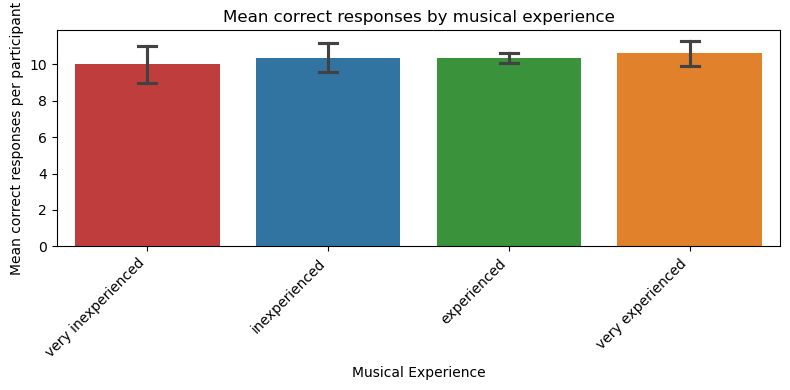

In [ ]:
# impact of musical experience on experiment result
translation_dict = {"sehr unerfahren": "very inexperienced",
                    "unerfahren": "inexperienced",
                    "erfahren": "experienced",
                    "sehr erfahren": "very experienced"
                    }

df["musical_experience"] = df["musical_experience"].map(translation_dict)

participant_summary = (
    df.groupby(["participant_id", "musical_experience"], as_index=False)["correct_response"]
      .sum()
)


order = ["very inexperienced", "inexperienced", "experienced", "very experienced"]


plt.figure(figsize=(8, 4))
sns.barplot(
    data=participant_summary,
    x="musical_experience",
    y="correct_response",
    order=order,   
    errorbar="se",     
    capsize=0.1,       
    hue="musical_experience",
    legend=False
)
plt.ylabel("Mean correct responses per participant")
plt.xlabel("Musical Experience")
plt.title("Mean correct responses by musical experience")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# participant_summary["musical_experience"] = participant_summary["musical_experience"].astype("category")
# participant_summary["experience_code"] = participant_summary["musical_experience"].cat.codes

# print("Experience categories:", participant_summary["musical_experience"].cat.categories.tolist())
# print(participant_summary.groupby("musical_experience", observed=True)["correct_response"].agg(["count", "mean", "median"]))

# print("\nPearson correlation (category codes):",
#       participant_summary["experience_code"].corr(participant_summary["correct_response"]))
# print("\nSpearman correlation (category codes):",
#       participant_summary["experience_code"].corr(participant_summary["correct_response"], method="spearman"))

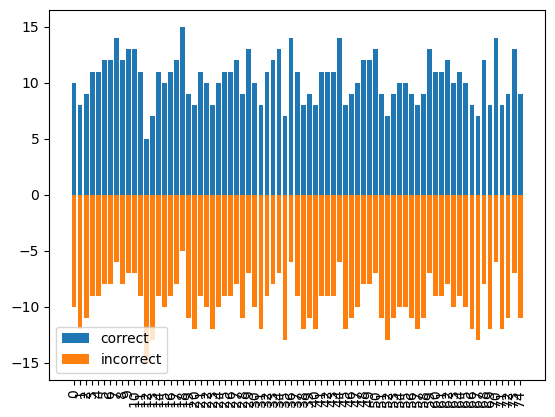

In [130]:
# Correct response distribution

responses_indiv = pd.Series([(g["correct_response"].sum(), 20 - g["correct_response"].sum()) for n, g in df.groupby("timestamp") ])
# responses_indiv.value_counts().sort_index().plot(kind="bar", xlabel="Correct responses", ylabel="Number of participants");

correct = np.array([r[0] for r in responses_indiv])
incorrect = -np.array([r[1] for r in responses_indiv])

xx = np.arange(len(correct), dtype=int)

_, ax = plt.subplots()
ax.bar(xx, correct, label="correct")#
# ax.axhline(correct.mean(), c="k")

ax.bar(xx, incorrect, label="incorrect")
# ax.axhline(incorrect.mean(), c="k")
plt.xticks(xx, rotation=90)
plt.legend()


Mean: 2.080213903743316
Median:  2.1176470588235294


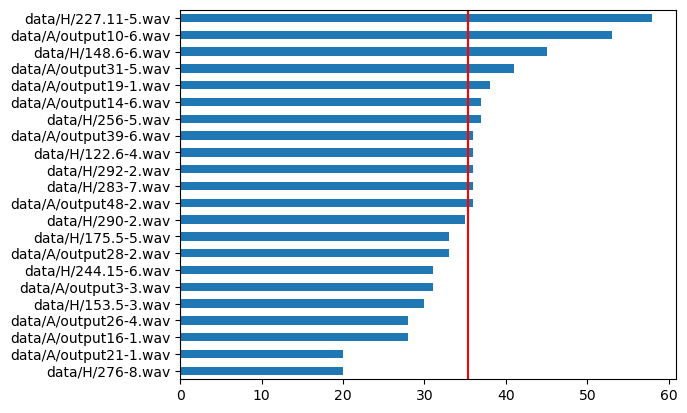

In [121]:
indices, values = zip(*[(n, g["correct_response"].sum()) for n, g in df.groupby("stimulus")])

responses_piece = pd.Series(values, index=indices).sort_index()

_, ax = plt.subplots()
responses_piece.sort_values().plot(kind="barh", ax=ax)
avg = responses_piece.mean()
ax.axvline(avg, c="red")
# ax.axvline(responses_piece.median(), c="green")
print("Mean:", responses_piece.mean() / 17)
print("Median: ", responses_piece.median() /17);

75
75


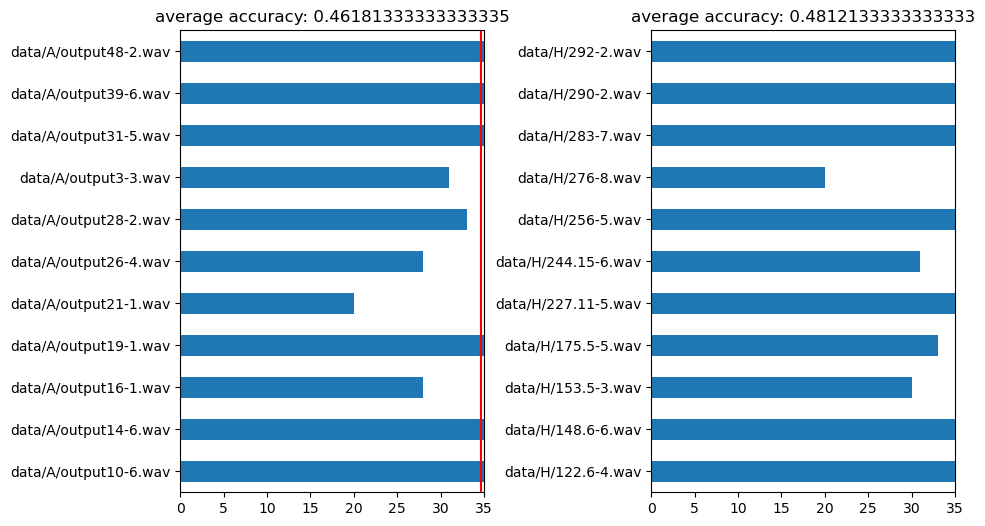

In [ ]:
responses_A, responses_H = responses_piece[:11], responses_piece[11:]

_, axes = plt.subplots(1,2, figsize=(10,6), gridspec_kw={"wspace": .55})
for i, r in enumerate([responses_A, responses_H]):
    r.plot(kind="barh", ax=axes[i])
    avg = round(r.mean(), 3)
    axes[i].axvline(avg, c="red")
    axes[i].set_title(f"average accuracy: {avg/len(unique_participants)}")
    axes[i].set_xlim(0,35)


**Notizen**

- Alle Beispiele von Menschen einspielen lassen? Oder besser erklären, dass alles maschinell ab gespielt wird.
- Vergleichen: Einspielung vs Synthetisch?
- Bach-Choräle beliebt zum Trainieren, aber wenig Kontakt für Schüler. Wie funktioniert es bei "zugänglicheren" Sachen?
- Frage erweitern: Kann KI-Musik von menschlicher unterscheiden? Ausweitung der Genres etc.
- Notentext einbeziehen? --> Hypothese: Aufgabe wird leichter
- Mit SCB durchführen (oder Choräle spielen lassen)